# `eval.py` — step by step

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from einops import rearrange, repeat
from torch.utils.data import DataLoader

from architectures import ResNet5, ResUNet, StateOnlyPredictor, Projector, DetHead
from image_decoder import ImageDecoder
from jepa import JEPA, JEPAProbe
from losses import VCLoss, SquareLossSeq
from moving_mnist import MovingMNISTDet

Instantiate all models with **random weights** — shapes are real, predictions are noise.

In [2]:
D_OBS = 1   # greyscale
H_ENC = 32  # encoder hidden dim
D_STC = 16  # representation dim
H_PRE = 32  # predictor hidden dim

encoder        = ResNet5(D_OBS, H_ENC, D_STC)
predictor_net  = ResUNet(2 * D_STC, H_PRE, D_STC)
predictor      = StateOnlyPredictor(predictor_net, context_length=2)
projector      = Projector(f"{D_STC}-{D_STC*4}-{D_STC*4}")
regularizer    = VCLoss(10.0, 100.0, proj=projector)
pred_loss      = SquareLossSeq(projector)
jepa           = JEPA(encoder, encoder, predictor, regularizer, pred_loss)

decoder        = ImageDecoder(D_STC, D_OBS)
dethead        = DetHead(D_STC, H_PRE, D_OBS)
pixel_decoder  = JEPAProbe(jepa, decoder, nn.MSELoss())
detection_head = JEPAProbe(jepa, dethead, nn.BCELoss())

print("All models instantiated.")

All models instantiated.


Load one batch from the validation split.

In [3]:
val_dl = DataLoader(MovingMNISTDet(split="val"), batch_size=32, drop_last=True)
batch  = next(iter(val_dl))

print("batch['video'] shape:         ", batch["video"].shape)           # (32, 1, 10, 64, 64)
print("batch['digit_location'] shape:", batch["digit_location"].shape)  # (32, 10, 8, 8)

batch['video'] shape:          torch.Size([32, 1, 10, 64, 64])
batch['digit_location'] shape: torch.Size([32, 10, 8, 8])


---
## 1. `add_label_to_video`

PIL works with `(T, H, W, C)` uint8 arrays. Start with a random one.

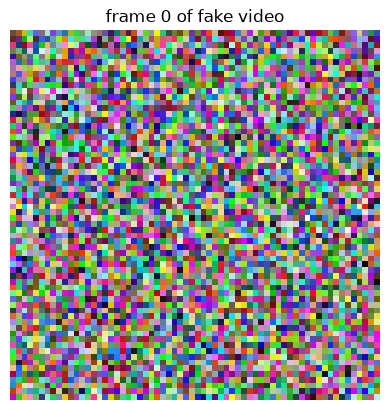

shape: (3, 64, 64, 3)


In [4]:
fake_video = np.random.randint(0, 255, (3, 64, 64, 3), dtype=np.uint8)

plt.imshow(fake_video[0])
plt.title("frame 0 of fake video")
plt.axis("off")
plt.show()
print("shape:", fake_video.shape)

`draw.rectangle([0, 0, W, 20], fill=(40, 40, 40, 200))` — the 4th value is alpha. 200/255 ≈ 78% opaque.

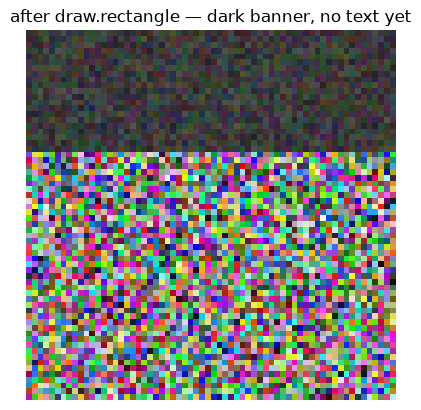

In [5]:
T, H, W, C = fake_video.shape

frame = Image.fromarray(fake_video[0])
draw  = ImageDraw.Draw(frame, "RGBA")          # RGBA mode enables per-pixel alpha
draw.rectangle([0, 0, W, 20], fill=(40, 40, 40, 200))

plt.imshow(np.array(frame))
plt.title("after draw.rectangle — dark banner, no text yet")
plt.axis("off")
plt.show()

`draw.text((4, 4), label, ...)` — 4 px padding from top-left corner.

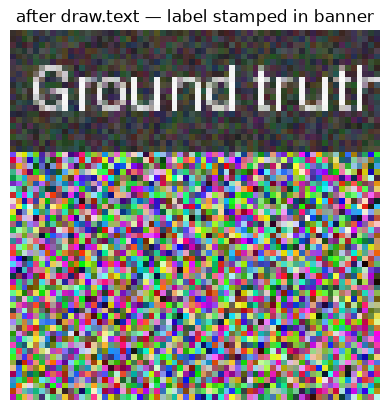

In [6]:
font = ImageFont.load_default()    # PIL's built-in bitmap font, no file needed
draw.text((4, 4), "Ground truth", fill=(255, 255, 255), font=font)

plt.imshow(np.array(frame))
plt.title("after draw.text — label stamped in banner")
plt.axis("off")
plt.show()

Now the full function, applied to a real Moving MNIST frame.

In [7]:
def add_label_to_video(video, label):
    font = ImageFont.load_default()
    T, H, W, C = video.shape
    labeled_frames = []
    for t in range(T):
        frame = Image.fromarray(video[t])
        draw  = ImageDraw.Draw(frame, "RGBA")
        draw.rectangle([0, 0, W, 20], fill=(40, 40, 40, 200))
        draw.text((4, 4), label, fill=(255, 255, 255), font=font)
        labeled_frames.append(np.array(frame))
    return np.stack(labeled_frames, axis=0)

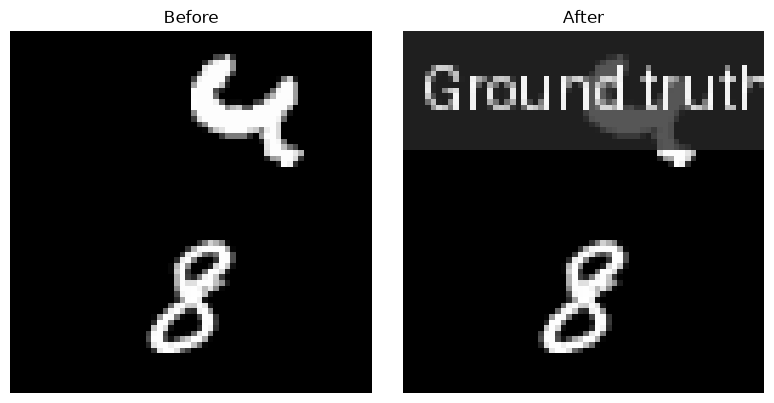

In [8]:
# batch["video"][0, 0, 0] → first sample, channel 0, frame 0 → (64, 64) float [0,1]
mnist_frame     = batch["video"][0, 0, 0].numpy()
mnist_uint8     = (mnist_frame * 255).astype(np.uint8)
mnist_rgb       = np.stack([mnist_uint8] * 3, axis=-1)   # (64, 64, 3)
mnist_as_video  = mnist_rgb[np.newaxis]                   # (T=1, 64, 64, 3)

labeled = add_label_to_video(mnist_as_video, "Ground truth")

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(mnist_rgb, cmap="gray")
axes[0].set_title("Before")
axes[1].imshow(labeled[0])
axes[1].set_title("After")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## 2. `visualize_videos`

### 2a — Encode the batch

In [9]:
x = batch["video"]
print("x shape:", x.shape)   # (32, 1, 10, 64, 64)

x shape: torch.Size([32, 1, 10, 64, 64])


In [10]:
with torch.no_grad():
    x_jepa = jepa.encoder(x)
print("x_jepa shape:", x_jepa.shape)   # (32, 16, 10, 64, 64)

x_jepa shape: torch.Size([32, 16, 10, 64, 64])


In [11]:
T = x.shape[2]
print(f"T = {T}")   # 10

T = 10


### 2b — Unroll

`return_all_steps=True` returns a **list** instead of a single tensor — one entry per rollout iteration.

In [12]:
with torch.no_grad():
    preds, _ = jepa.unroll(
        x,
        actions=None,
        nsteps=T - 2,
        unroll_mode="parallel",
        compute_loss=False,
        return_all_steps=True,
    )

print(f"len(preds)    : {len(preds)}")          # 8  (= nsteps = T-2)
print(f"preds[0].shape: {preds[0].shape}")      # (32, 16, 8, 64, 64)

len(preds)    : 8
preds[0].shape: torch.Size([32, 16, 8, 64, 64])


In [13]:
# preds[k] = the full representation sequence produced after k+1 parallel rollout steps
for k in range(len(preds)):
    print(f"  preds[{k}]: {k+1}-step prediction   shape {list(preds[k].shape)}")

  preds[0]: 1-step prediction   shape [32, 16, 8, 64, 64]
  preds[1]: 2-step prediction   shape [32, 16, 8, 64, 64]
  preds[2]: 3-step prediction   shape [32, 16, 8, 64, 64]
  preds[3]: 4-step prediction   shape [32, 16, 8, 64, 64]
  preds[4]: 5-step prediction   shape [32, 16, 8, 64, 64]
  preds[5]: 6-step prediction   shape [32, 16, 8, 64, 64]
  preds[6]: 7-step prediction   shape [32, 16, 8, 64, 64]
  preds[7]: 8-step prediction   shape [32, 16, 8, 64, 64]


### 2c — One-step prediction

Start from GT frames 1…9 (skip frame 0 — can't predict it with no prior context).

In [14]:
one_step_pred = x_jepa[:, :, 1:].clone()
print("one_step_pred shape:", one_step_pred.shape)  # (32, 16, 9, 64, 64)
print()
print("Before fill: slots 0..8 are all GT reps (frames 1..9)")

one_step_pred shape: torch.Size([32, 16, 9, 64, 64])

Before fill: slots 0..8 are all GT reps (frames 1..9)


In [16]:
# slot 0 stays as GT frame 1 (context anchor)
# slots 1..8 ← preds[0] (1-step predictions for frames 2..9)
one_step_pred[:, :, 1:] = preds[0]

print("After fill:")
print("  slot 0 → GT frame 1        (never replaced)")
print("  slots 1..8 → preds[0][:,:,0..7]   (1-step predictions)")
print()
print("one_step_pred shape:", one_step_pred.shape)  # unchanged

After fill:
  slot 0 → GT frame 1        (never replaced)
  slots 1..8 → preds[0][:,:,0..7]   (1-step predictions)

one_step_pred shape: torch.Size([32, 16, 9, 64, 64])


In [17]:
# pixel_decoder.head is the ImageDecoder — decodes representation space back to pixels
with torch.no_grad():
    one_step_reconstruction = pixel_decoder.head(one_step_pred)
print("one_step_reconstruction shape:", one_step_reconstruction.shape)  # (32, 1, 9, 64, 64)

one_step_reconstruction shape: torch.Size([32, 1, 9, 64, 64])


### 2d — Multi-step rollout (the diagonal)

At each time step `t`, use the prediction from the rollout that is exactly `t` steps deep — no GT used after the first two context frames.

In [18]:
rollout = x_jepa[:, :, 1:].clone()

print(f"{'t':>4} | {'slots overwritten':>30} | source")
print("-" * 65)
for t in range(1, T - 1):
    rollout[:, :, t:] = preds[t - 1][:, :, t - 1:]
    print(f"  {t:>2} | slots {t}..{T-2:>2}                     | preds[{t-1}][:,:,{t-1}:]")

print()
print("Final slot mapping:")
print("  slot 0 → GT frame 1  (never overwritten)")
for t in range(1, T - 1):
    print(f"  slot {t} → preds[{t-1}][:,:,{t-1}]   ({t}-step prediction)")

   t |              slots overwritten | source
-----------------------------------------------------------------
   1 | slots 1.. 8                     | preds[0][:,:,0:]
   2 | slots 2.. 8                     | preds[1][:,:,1:]
   3 | slots 3.. 8                     | preds[2][:,:,2:]
   4 | slots 4.. 8                     | preds[3][:,:,3:]
   5 | slots 5.. 8                     | preds[4][:,:,4:]
   6 | slots 6.. 8                     | preds[5][:,:,5:]
   7 | slots 7.. 8                     | preds[6][:,:,6:]
   8 | slots 8.. 8                     | preds[7][:,:,7:]

Final slot mapping:
  slot 0 → GT frame 1  (never overwritten)
  slot 1 → preds[0][:,:,0]   (1-step prediction)
  slot 2 → preds[1][:,:,1]   (2-step prediction)
  slot 3 → preds[2][:,:,2]   (3-step prediction)
  slot 4 → preds[3][:,:,3]   (4-step prediction)
  slot 5 → preds[4][:,:,4]   (5-step prediction)
  slot 6 → preds[5][:,:,5]   (6-step prediction)
  slot 7 → preds[6][:,:,6]   (7-step prediction)
  slot 8 → preds

In [19]:
with torch.no_grad():
    rollout_reconstruction = pixel_decoder.head(rollout)
print("rollout_reconstruction shape:", rollout_reconstruction.shape)  # (32, 1, 9, 64, 64)

rollout_reconstruction shape: torch.Size([32, 1, 9, 64, 64])


### 2e — Detection heatmap

`detection_head.head` is `DetHead` — it pools spatial features to 8×8 and predicts a binary location map.

In [20]:
with torch.no_grad():
    loc_prediction = detection_head.head(rollout)
print("loc_prediction shape:", loc_prediction.shape)   # (32, 9, 8, 8)

loc_prediction shape: torch.Size([32, 9, 8, 8])


In [21]:
# F.interpolate on a 4D tensor treats dims as (N, C, H, W)
# here: N=32, C=9 (time), H=8, W=8 → upsample H,W to 64x64
loc_prediction = F.interpolate(loc_prediction, (x.shape[-2], x.shape[-1]), mode="nearest")
print("After interpolate:", loc_prediction.shape)   # (32, 9, 64, 64)

After interpolate: torch.Size([32, 9, 64, 64])


In [22]:
# Replicate across 3 colour channels so we can zero out R and G
loc_prediction = repeat(loc_prediction, "b t h w -> b c t h w", c=3).clone()
print("After repeat:", loc_prediction.shape)   # (32, 3, 9, 64, 64)

After repeat: torch.Size([32, 3, 9, 64, 64])


In [23]:
# Zero out R (ch 0) and G (ch 1) → only B (ch 2) survives → pure blue heatmap
loc_prediction[:, :2].fill_(0)

print("Channel 0 (R) max:", loc_prediction[:, 0].max().item())   # 0.0
print("Channel 1 (G) max:", loc_prediction[:, 1].max().item())   # 0.0
print("Channel 2 (B) max:", loc_prediction[:, 2].max().item())   # > 0

Channel 0 (R) max: 0.0
Channel 1 (G) max: 0.0
Channel 2 (B) max: 0.5150052905082703


### 2f — Blend

`rollout_reconstruction` is `(32,1,9,64,64)` and `loc_prediction` is `(32,3,9,64,64)`. PyTorch broadcasts the channel dim 1→3.

In [24]:
detection_overlay = 0.2 * rollout_reconstruction + 0.8 * loc_prediction
print("detection_overlay shape:", detection_overlay.shape)   # (32, 3, 9, 64, 64)

detection_overlay shape: torch.Size([32, 3, 9, 64, 64])


### 2g — `scale_and_convert_to_uint8`

Resizes to 100×100, converts greyscale→RGB, scales to uint8, reorders axes to `(T,H,W,C)` for PIL.

In [25]:
def scale_and_convert_to_uint8(tensor):
    tensor = F.interpolate(tensor, (100, 100), mode="bilinear")
    if tensor.shape[0] == 1:
        tensor = tensor.repeat(3, 1, 1, 1)          # greyscale → RGB
    tensor = torch.clamp(tensor * 255, 0, 255).to(torch.uint8)
    tensor = rearrange(tensor, "c t h w -> t h w c").cpu().numpy()
    return tensor

In [26]:
gt = x[:, :, 1:]   # (32, 1, 9, 64, 64) — skip frame 0 to align with predictions

gt_sample = gt[0]   # (1, 9, 64, 64) — per-video shape is (C, T, H, W)
print("Before:", list(gt_sample.shape))

gt_uint8 = scale_and_convert_to_uint8(gt_sample)
print("After: ", list(gt_uint8.shape))   # (9, 100, 100, 3)

Before: [1, 9, 64, 64]
After:  [9, 100, 100, 3]


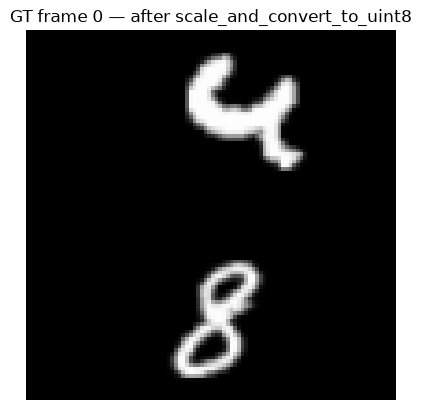

In [27]:
plt.imshow(gt_uint8[0])
plt.title("GT frame 0 — after scale_and_convert_to_uint8")
plt.axis("off")
plt.show()

### 2h — Label, transpose, and stack the 3 rows

`np.concatenate(videos, axis=2)` — axis 2 is H in `(T,C,H,W)`, so this stacks the three strips **vertically**.

In [28]:
rows   = [gt, rollout_reconstruction, detection_overlay]
labels = ["Ground truth", "Predicted rollout", "Digit detections"]
b = 0   # sample index

videos = [row[b] for row in rows]
print("Per-row shapes:       ", [list(v.shape) for v in videos])
# [(1,9,64,64), (1,9,64,64), (3,9,64,64)]

videos = [scale_and_convert_to_uint8(v) for v in videos]
print("After scale_and_convert:", [list(v.shape) for v in videos])
# [(9,100,100,3), (9,100,100,3), (9,100,100,3)]

videos = [add_label_to_video(v, lbl) for v, lbl in zip(videos, labels)]
videos = [v.transpose(0, 3, 1, 2) for v in videos]   # (T,H,W,C) → (T,C,H,W)
print("After transpose:      ", [list(v.shape) for v in videos])
# [(9,3,100,100), (9,3,100,100), (9,3,100,100)]

combined = np.concatenate(videos, axis=2)   # stack along H
print("Final combined shape: ", list(combined.shape))   # (9, 3, 300, 100)

Per-row shapes:        [[1, 9, 64, 64], [1, 9, 64, 64], [3, 9, 64, 64]]
After scale_and_convert: [[9, 100, 100, 3], [9, 100, 100, 3], [9, 100, 100, 3]]
After transpose:       [[9, 3, 100, 100], [9, 3, 100, 100], [9, 3, 100, 100]]
Final combined shape:  [9, 3, 300, 100]


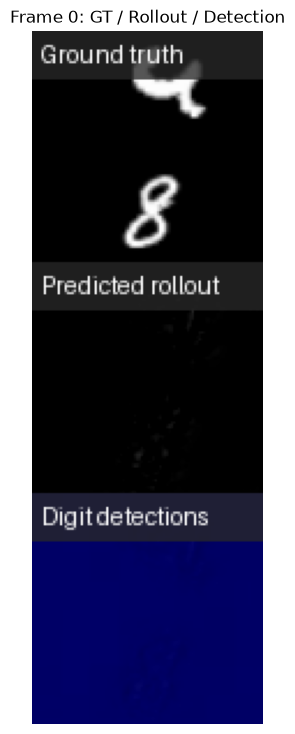

In [29]:
# Frame 0 of the combined video — 3 rows stacked vertically
frame0 = combined[0].transpose(1, 2, 0)   # (C,H,W) → (H,W,C)
plt.figure(figsize=(3, 9))
plt.imshow(frame0)
plt.title("Frame 0: GT / Rollout / Detection")
plt.axis("off")
plt.show()

---
## 3. `validation_loop` (1 batch)

### 3a — eval mode

Switches BatchNorm to use running statistics and disables Dropout.

In [30]:
jepa.eval()
detection_head.eval()
pixel_decoder.eval()
print("All modules in eval mode.")

All modules in eval mode.


### 3b — probe losses

In [31]:
x_val   = batch["video"]
loc_map = batch["digit_location"]

print("x_val shape:  ", x_val.shape)    # (32, 1, 10, 64, 64)
print("loc_map shape:", loc_map.shape)  # (32, 10, 8, 8)

x_val shape:   torch.Size([32, 1, 10, 64, 64])
loc_map shape: torch.Size([32, 10, 8, 8])


In [32]:
# JEPAProbe.forward(observations, targets):
#   → encode with frozen JEPA → decode with head → compute hcost(output, targets)
# Both args are x_val: we're measuring how well we can reconstruct pixels from representations.
with torch.inference_mode():
    recon_loss = pixel_decoder(x_val, x_val)
print("recon_loss:", float(recon_loss.item()))

recon_loss: 0.044719453901052475


In [33]:
# Same pattern but target is loc_map — did the representation learn where the digit is?
with torch.inference_mode():
    det_loss = detection_head(x_val, loc_map)
print("det_loss:", float(det_loss.item()))

det_loss: 0.6930704712867737


### 3c — per-rollout-depth AP scores

`AP_k` = average precision when predicting `k+1` steps into the future. `loc_map[:, 2:]` skips the 2 GT context frames to align targets with predictions.

In [34]:
T_val = x_val.shape[2]

with torch.inference_mode():
    preds_val, _ = jepa.unroll(
        x_val,
        actions=None,
        nsteps=T_val - 2,
        unroll_mode="parallel",
        compute_loss=False,
        return_all_steps=True,
    )

print(f"len(preds_val):      {len(preds_val)}")          # 8
print(f"preds_val[0].shape:  {preds_val[0].shape}")      # (32, 16, 8, 64, 64)
print(f"loc_map[:, 2:] shape:{loc_map[:, 2:].shape}")    # (32, 8, 8, 8)

len(preds_val):      8
preds_val[0].shape:  torch.Size([32, 16, 8, 64, 64])
loc_map[:, 2:] shape:torch.Size([32, 8, 8, 8])


In [35]:
# detection_head.head.score(preds_val, loc_map[:, 2:]) would give:
#   [AP_0, AP_1, ..., AP_6]   (7 values = len(preds)-1)
#
# ⚠️  Bug in DetHead.score (architectures.py line 258):
#     x.sqeueeze(1) should be x.squeeze(1)
#   This raises AttributeError at runtime. Fix the typo to run it.

print("detection_head.head.score would return", len(preds_val) - 1, "AP scores:")
for k in range(len(preds_val) - 1):
    print(f"  AP_{k}  ← {k+1}-step prediction vs loc_map[:, {k+2}]")

detection_head.head.score would return 7 AP scores:
  AP_0  ← 1-step prediction vs loc_map[:, 2]
  AP_1  ← 2-step prediction vs loc_map[:, 3]
  AP_2  ← 3-step prediction vs loc_map[:, 4]
  AP_3  ← 4-step prediction vs loc_map[:, 5]
  AP_4  ← 5-step prediction vs loc_map[:, 6]
  AP_5  ← 6-step prediction vs loc_map[:, 7]
  AP_6  ← 7-step prediction vs loc_map[:, 8]


### 3d — aggregate metrics

In [36]:
import collections

metrics = collections.defaultdict(list)
metrics["val/recon_loss"].append(float(recon_loss.item()))
metrics["val/det_loss"].append(float(det_loss.item()))

# After the full val loop, average across batches:
metrics_final = {k: float(np.mean(v)) for k, v in metrics.items()}
print(metrics_final)

{'val/recon_loss': 0.044719453901052475, 'val/det_loss': 0.6930704712867737}


### 3e — restore train mode

In [37]:
jepa.train()
detection_head.train()
pixel_decoder.train()
print("All modules restored to train mode.")

All modules restored to train mode.
